In [71]:
from math import log10, sqrt

from scipy.integrate import solve_ivp
from scipy.constants import pi
import numpy as np

EPSILON_0_MEV_PER_FM3 = 150 # MeV/fm^3
MEV_PER_FM3_TO_SM_PER_KM_3 = 8.96498313e-7  # Conversion factor to convert from MeV/fm^3 to M☉/km^3
EPSILON_0 = EPSILON_0_MEV_PER_FM3 * MEV_PER_FM3_TO_SM_PER_KM_3  # M☉/km^3
 

@np.vectorize
def scale_mev_fm3_to_sm_km3(quantity: float) -> float:
    return quantity * MEV_PER_FM3_TO_SM_PER_KM_3


def gamma(point1: tuple[float, float], point2: tuple[float, float]):
    eps1, p1 = point1
    eps2, p2 = point2
    quantities = [eps1, eps2, p1, p2]
    [eps1, eps2, p1, p2] = scale_mev_fm3_to_sm_km3(quantities)
    return log10(p2 / p1) / log10(eps2 / eps1)


def kappa(point: tuple[float, float], gamma: float):
    eps, p = point
    p = p * MEV_PER_FM3_TO_SM_PER_KM_3
    eps = eps * MEV_PER_FM3_TO_SM_PER_KM_3
    return p / (eps**gamma)


def kappa_prime(kappa, gamma):
    return kappa * (EPSILON_0 ** (gamma - 1))


# Scaling to dimensionless
EOS_POINT_1 = (100, 1)  # (ε, P) in MeV/fm^3
EOS_POINT_2 = (180, 3)  # (ε, P) in MeV/fm^3
# TEMP (ref gamma): 1.869066370961403
GAMMA = 2.75 * 1.869066370961403 # Dimensionless
KAPPA = kappa(EOS_POINT_1, GAMMA)  # Units to cancel out epsilon^gamma where epsilon is in M☉/km^3.
KAPPA_PRIME = kappa_prime(KAPPA, GAMMA) # Dimensionless

# Scaling back to dimensional quantities
G_NU = 1.4766  # km/M☉
A = 1 / sqrt(G_NU * EPSILON_0) # Re-scaling constant
B = 1 / sqrt(G_NU**3 * EPSILON_0) # Re-scaling constant

def eos_epsilon(p_prime):
    return (p_prime / KAPPA_PRIME) ** (1 / GAMMA)

def mass_nu(m_prime):
    return B * m_prime


def radius_nu(r_prime):
    return A * r_prime


def tov_rhs(r, state):
    p, m = state
    if m <= 0:
        raise ValueError("r0 is too small")
    if p <= 0:
        return (0, m)
    epsilon = eos_epsilon(p)
    f1 = -((m * epsilon) / r**2)
    f2 = 1 + (p / epsilon)
    f3 = 1 + (4 * pi * r**3 * p / m)
    f4 = 1 / (1 - (2 * m / r))
    dp_dr = f1 * f2 * f3 * f4
    dm_dr = (4 * pi) * r**2 * epsilon
    return (dp_dr, dm_dr)


def surface_event(r, state):
    p, _ = state
    return p


surface_event.terminal = True  # type: ignore
surface_event.direction = -1  # type: ignore


def solve_tov(p_c) -> tuple[float, float]:
    r_0 = 1e-5
    epsilon = eos_epsilon(p_c)
    m_0 = (4 * pi / 3) * r_0**3 * epsilon
    solutions = solve_ivp(
        tov_rhs,
        t_span=(r_0, 50),  # Should terminate before reaching endpoint.
        y0=(p_c, m_0),
        events=surface_event,
    )
    r_surface = solutions.t_events[0][0]
    m_surface = solutions.y_events[0][0][1]
    return (r_surface, m_surface)


def test_single_p_c():
    p_c = 100 * MEV_PER_FM3_TO_SM_PER_KM_3
    p_prime = p_c / EPSILON_0
    r, m = solve_tov(p_prime)
    r = radius_nu(r)
    m = mass_nu(m)
    # For Pressure = 100 MeV/fm^3
    # Radius = 7.473417814092245 km
    # Mass = 0.5972517874652591 solar masses
    print(f"{r = } km | {m = } solar masses")


def generate_mass_radius_curve(p_start, p_end) -> tuple[list[float], list[float]]:
    pressure_range = np.logspace(p_start, p_end, num=200)
    radii = []
    masses = []
    for p_c in pressure_range:
        # Convert central pressure to the correct units.
        p_c = p_c * MEV_PER_FM3_TO_SM_PER_KM_3
        p_prime = p_c / EPSILON_0
        r, m = solve_tov(p_prime)
        r = radius_nu(r)
        m = mass_nu(m)
        radii.append(r)
        masses.append(m)
    return (radii, masses)

def DEBUG():
    print(f"{EOS_POINT_1 = }")
    print(f"{EOS_POINT_2 = }")
    print(f"{GAMMA = }")
    print(f"{KAPPA = }")
    print(f"{KAPPA_PRIME = }")
    print(f"{G_NU = }")
    print(f"{A = }")
    print(f"{B = }")

# EOS_POINT_1 = (100, 1)
# EOS_POINT_2 = (180, 3)
# GAMMA = 2.0
# KAPPA = 111.54510672235921
# KAPPA_PRIME = 0.014999999999999998
# G_NU = 1.4766
# A = 70.96565247024616
# B = 48.060173689723804
DEBUG()

EOS_POINT_1 = (100, 1)
EOS_POINT_2 = (180, 3)
GAMMA = 5.139932520143859
KAPPA = 570390186940698.0
KAPPA_PRIME = 0.053580397335655346
G_NU = 1.4766
A = 70.96565247024616
B = 48.060173689723804


Text(0.5, 1.0, 'Mass-Radius Curve')

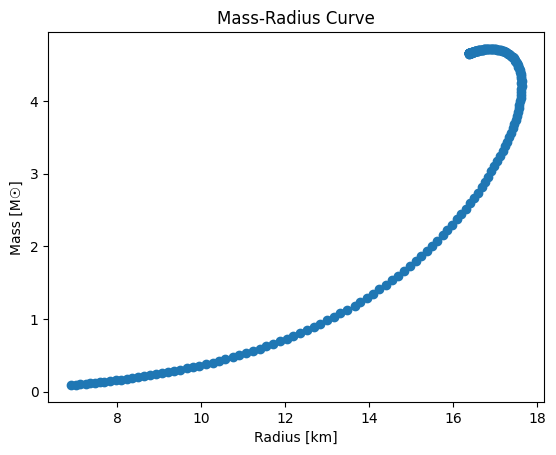

In [72]:
import matplotlib.pyplot as plt

radii, masses = generate_mass_radius_curve(0, 5)

fig, ax1 = plt.subplots()
ax1.scatter(radii, masses)
ax1.set_ylabel("Mass [M☉]")
ax1.set_xlabel("Radius [km]")
ax1.set_title("Mass-Radius Curve")

GAMMA = np.float64(1.8690663709614028)
K = np.float64(0.00018275415434762654) [MeV-fm units]


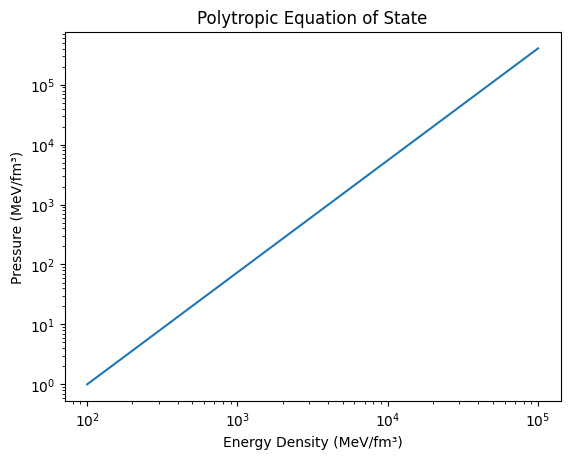

In [73]:
import numpy as np
import matplotlib.pyplot as plt

EOS_POINT_1 = (100, 1)  # (ε, P) in MeV/fm^3
EOS_POINT_2 = (180, 3)  # (ε, P) in MeV/fm^3

eps1, p1 = EOS_POINT_1
eps2, p2 = EOS_POINT_2

GAMMA = np.log10(p2 / p1) / np.log10(eps2 / eps1)
K = p1 / (eps1**GAMMA)


@np.vectorize
def eos_p(eps: float):
    return K * eps**GAMMA


epsilons = np.logspace(2, 5, 200)
pressures = eos_p(epsilons)

fig, ax1 = plt.subplots()

ax1.loglog(epsilons, pressures)
ax1.set_xlabel("Energy Density (MeV/fm³)")
ax1.set_ylabel("Pressure (MeV/fm³)")
ax1.set_title("Polytropic Equation of State")

print(f"{GAMMA = }")
print(f"{K = } [MeV-fm units]")

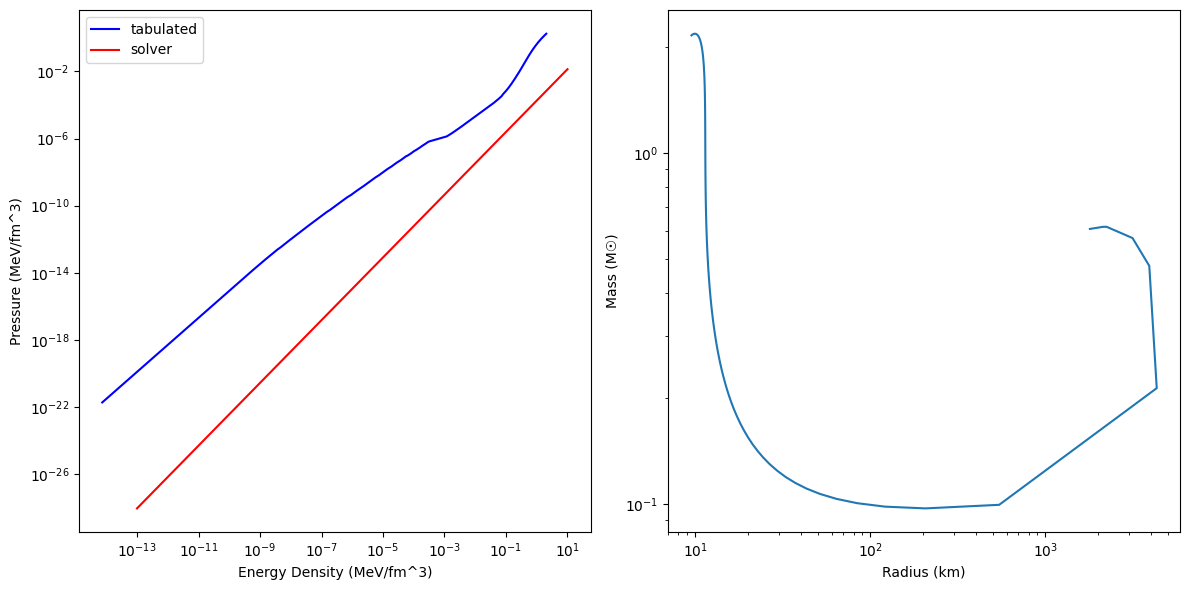

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

EOS_DATA_FILE_PATH = "eos_68.txt"
MASS_RADIUS_DATA_FILE_PATH = "mrl_eos_68.txt"

with open(EOS_DATA_FILE_PATH, 'r') as f:
    # Skip the comments are the start of the file
    pos = 0
    while f.readline().startswith("#"):
        pos = f.tell()
    f.seek(pos) # Go back 1 line.
    mrl_df = pd.read_table(f)
tabulated_p_values = mrl_df['p']
tabulated_eps_values = mrl_df['e']

with open(MASS_RADIUS_DATA_FILE_PATH, 'r') as f:
    # Skip the comments are the start of the file
    pos = 0
    while f.readline().startswith("#"):
        pos = f.tell()
    f.seek(pos)  # Go back 1 line.
    mrl_df = pd.read_table(f, sep=' ')
tabulated_m_values = mrl_df['m']
tabulated_r_values = mrl_df['r']

solver_eps_values = np.logspace(-13, 1)
solver_p_values = eos_p(solver_eps_values)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches(12, 6)

ax1.loglog(tabulated_eps_values, tabulated_p_values, color = 'blue', label = 'tabulated')
ax1.loglog(solver_eps_values, solver_p_values, color = 'red', label = 'solver')
ax1.set_xlabel("Energy Density (MeV/fm^3)")
ax1.set_ylabel("Pressure (MeV/fm^3)")
ax1.legend()

ax2.loglog(tabulated_r_values, tabulated_m_values)
ax2.set_xlabel("Radius (km)")
ax2.set_ylabel("Mass (M☉)")

fig.tight_layout()
